# E1 + Scaling

Train Transformer-small vs Hyena-small (WikiText-2) → `results/*.csv` + plot.

**Dùng:** Runtime → T4 GPU → Run all. Lần chạy đầy đủ (20 epoch × 2 model + scaling tới L=4096) tốn ~50–70 phút; cuối notebook tải `results.zip`.

## 1. Kiểm tra GPU

In [1]:
!nvidia-smi -L
import torch
print('torch', torch.__version__, '| CUDA available:', torch.cuda.is_available())
assert torch.cuda.is_available(), 'CHƯA bật GPU! Vào Runtime > Change runtime type > T4 GPU rồi Run all lại.'

GPU 0: Tesla T4 (UUID: GPU-e64f48e4-ab94-b576-2909-51362684624e)
torch 2.11.0+cu128 | CUDA available: True


## 2. Clone repo + cài thư viện
Thêm `datasets` + `transformers` (các lib khác đã có sẵn trên Colab).

In [2]:
%cd /content
![ -d CS2308-Hyena-Hierarchy-Long-Context-NLP ] || git clone https://github.com/minhtien0498/CS2308-Hyena-Hierarchy-Long-Context-NLP.git
%cd CS2308-Hyena-Hierarchy-Long-Context-NLP
!git pull -q
# Pin version để tránh HfUriError (datasets/hub mới đổi quy ước tên dataset)
!pip install -q "datasets<3" "huggingface_hub<0.26" transformers

/content
Cloning into 'CS2308-Hyena-Hierarchy-Long-Context-NLP'...
remote: Enumerating objects: 218, done.
remote: Counting objects: 100% (218/218), done.
remote: Compressing objects: 100% (168/168), done.
remote: Total 218 (delta 81), reused 179 (delta 44), pack-reused 0 (from 0)
Receiving objects: 100% (218/218), 5.99 MiB | 27.40 MiB/s, done.
Resolving deltas: 100% (81/81), done.
/content/CS2308-Hyena-Hierarchy-Long-Context-NLP
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.6 MB/s eta 0:00:00
     ━

## 3. E1 — Train PPL (L=256)
20 epoch để PPL hội tụ rõ (mỗi model ~25–30 phút trên T4). Muốn chạy thử nhanh thì giảm `--epochs`. Lưu `results/E1_*_L256.csv`.

In [3]:
!python train.py --model transformer --seq_len 256 --epochs 20 --batch_size 16

[Device] GPU: Tesla T4

  Run: transformer_L256_20260628_130634
  Model: transformer | Seq len: 256
  Epochs: 20 | Batch size: 16

[Data] Loading train dataloader...
[Tokenizer] Loading gpt2 (transformers tự cache)...
tokenizer_config.json: 100% 26.0/26.0 [00:00<00:00, 134kB/s]
vocab.json: 1.04MB [00:00, 7.14MB/s]
merges.txt: 456kB [00:00, 6.02MB/s]
tokenizer.json: 1.36MB [00:00, 6.85MB/s]
config.json: 100% 665/665 [00:00<00:00, 5.56MB/s]
[Dataset] Loading WikiText-2 split='train'...
Generating test split: 100% 4358/4358 [00:00<00:00, 100695.64 examples/s]
Generating train split: 100% 36718/36718 [00:00<00:00, 468289.76 examples/s]
Generating validation split: 100% 3760/3760 [00:00<00:00, 425232.10 examples/s]
[Dataset] Total characters: 10,916,756
[Tokenizer] Encoding...
Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors
[Dataset] Total tokens (train)

In [4]:
!python train.py --model hyena --seq_len 256 --epochs 20 --batch_size 16

[Device] GPU: Tesla T4

  Run: hyena_L256_20260628_133920
  Model: hyena | Seq len: 256
  Epochs: 20 | Batch size: 16

[Data] Loading train dataloader...
[Tokenizer] Loading gpt2 (transformers tự cache)...
[Dataset] Loading WikiText-2 split='train'...
[Dataset] Total characters: 10,916,756
[Tokenizer] Encoding...
Token indices sequence length is longer than the specified maximum sequence length for this model (2391884 > 1024). Running this sequence through the model will result in indexing errors
[Dataset] Total tokens (train): 2,391,884
[DataLoader] split=train | seq_len=256 | batch_size=16 | batches=584
[Data] Loading validation dataloader...
[Tokenizer] Loading gpt2 (transformers tự cache)...
[Dataset] Loading WikiText-2 split='validation'...
[Dataset] Total characters: 1,144,610
[Tokenizer] Encoding...
Token indices sequence length is longer than the specified maximum sequence length for this model (247289 > 1024). Running this sequence through the model will result in indexing err

## 4. E2/E3 — Runtime/memory scaling theo seq_len
Đo cả 2 model tới **L=4096** để thấy rõ O(L²) vs O(L log L). Dùng `--batch_size 4` để Transformer không OOM ở L lớn trên T4.

In [5]:
!python evaluate.py --model transformer --scaling --seq_lens 256 512 1024 2048 4096 --batch_size 4
!python evaluate.py --model hyena --scaling --seq_lens 256 512 1024 2048 4096 --batch_size 4


  Scaling Experiment: TRANSFORMER
  Seq lengths: [256, 512, 1024, 2048, 4096]

   Seq Len |    Time (ms) |   Mem (MB) |   Throughput (tok/s)
------------------------------------------------------------
       256 |        12.33 |      269.0 |                83061
       512 |        22.79 |      468.3 |                89864
      1024 |        52.29 |      866.2 |                78333
      2048 |       131.42 |     1669.6 |                62334
      4096 |       383.91 |     3297.3 |                42677

💾 Saved: results/E2_transformer_scale.csv

  Scaling Experiment: HYENA
  Seq lengths: [256, 512, 1024, 2048, 4096]

   Seq Len |    Time (ms) |   Mem (MB) |   Throughput (tok/s)
------------------------------------------------------------
       256 |        14.05 |      269.4 |                72862
       512 |        22.73 |      467.9 |                90090
      1024 |        45.50 |      863.7 |                90018
      2048 |        90.35 |     1653.4 |                90668

## 5. Xem kết quả + vẽ plot PPL


=== results/E1_hyena_L256.csv ===


,epoch,train_loss,val_loss,val_ppl,train_time_s,peak_mem_mb,lr
0,1,7.805812,6.335985,564.5250,96.37,3107.0,0.000300
1,2,5.984937,5.854176,348.6874,96.67,3107.0,0.000298
2,3,5.561725,5.617279,275.1397,96.78,3107.0,0.000293
3,4,5.293921,5.481070,240.1035,96.84,3107.0,0.000284
4,5,5.095232,5.381511,217.3504,96.84,3107.0,0.000272
5,6,4.936183,5.316307,203.6304,97.00,3107.0,0.000256
6,7,4.804838,5.257583,192.0168,97.20,3107.0,0.000239
7,8,4.693169,5.218743,184.7019,96.88,3107.0,0.000219
8,9,4.599418,5.194599,180.2959,96.89,3107.0,0.000198
9,10,4.515962,5.178315,177.3837,97.16,3107.0,0.000176



=== results/E1_transformer_L256.csv ===


,epoch,train_loss,val_loss,val_ppl,train_time_s,peak_mem_mb,lr
0,1,7.817168,6.442039,627.6856,83.97,2994.1,0.000300
1,2,6.116945,6.009555,407.3021,91.43,2994.1,0.000298
2,3,5.738031,5.789952,326.9973,92.32,2994.1,0.000293
3,4,5.491169,5.634897,280.0301,92.61,2994.1,0.000284
4,5,5.304200,5.534054,253.1682,92.60,2994.1,0.000272
5,6,5.151442,5.456693,234.3213,92.75,2994.1,0.000256
6,7,5.024773,5.403106,222.0952,92.98,2994.1,0.000239
7,8,4.919173,5.352966,211.2339,92.96,2994.1,0.000219
8,9,4.828342,5.320640,204.5148,92.77,2994.1,0.000198
9,10,4.750608,5.281936,196.7504,92.95,2994.1,0.000176



=== results/E2_transformer_scale.csv ===


,model,seq_len,time_ms,peak_mem_mb,throughput
0,transformer,256,12.328306,268.988281,83060.881409
1,transformer,512,22.790040,468.314453,89863.819280
2,transformer,1024,52.289772,866.201172,78332.718082
3,transformer,2048,131.422102,1669.646484,62333.503153
4,transformer,4096,383.909990,3297.318359,42676.670095



=== results/E3_hyena_scale.csv ===


,model,seq_len,time_ms,peak_mem_mb,throughput
0,hyena,256,14.053922,269.373047,72862.224642
1,hyena,512,22.732836,467.949219,90089.946035
2,hyena,1024,45.501806,863.710938,90018.405676
3,hyena,2048,90.351861,1653.406250,90667.750858
4,hyena,4096,179.709913,3233.953125,91169.149918


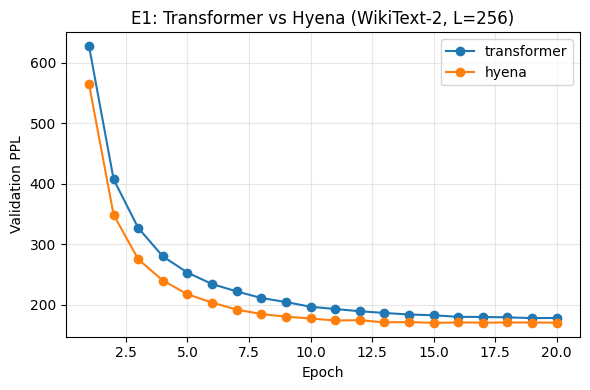

In [6]:
import glob, pandas as pd, matplotlib.pyplot as plt

for f in sorted(glob.glob('results/*.csv')):
    print('\n===', f, '===')
    display(pd.read_csv(f))

# Plot val PPL theo epoch cho 2 model E1
plt.figure(figsize=(6,4))
for model in ['transformer', 'hyena']:
    fp = f'results/E1_{model}_L256.csv'
    try:
        df = pd.read_csv(fp)
        plt.plot(df['epoch'], df['val_ppl'], marker='o', label=model)
    except FileNotFoundError:
        print('Chưa có', fp)
plt.xlabel('Epoch'); plt.ylabel('Validation PPL'); plt.title('E1: Transformer vs Hyena (WikiText-2, L=256)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig('results/plots/E1_ppl.png', dpi=120)
plt.show()

## 6. Tải kết quả về máy

In [7]:
!zip -r -q results.zip results
from google.colab import files
files.download('results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>